In [69]:
import pandas as pd
import sqlite3
from pandas.plotting import scatter_matrix

In [70]:
conn = sqlite3.connect('data/checking-logs.sqlite')

In [71]:
df = pd.io.sql.read_sql(
    """
    WITH num_commits AS (
        SELECT uid, COUNT(*) AS num_commits
        FROM checker
        WHERE uid LIKE 'user_%' AND labname != 'project1'
        GROUP BY uid
    ),
    user_pageviews AS (
        SELECT uid, COUNT(*) AS pageviews
        FROM pageviews
        WHERE uid LIKE 'user_%'
        GROUP BY uid
    ),
    avg_diff AS (
        SELECT t.uid,
               AVG((strftime('%s', t.first_commit_ts) - d.deadlines) / 3600) AS avg_diff
        FROM test t
        JOIN deadlines d ON t.labname = d.labs
        WHERE t.labname != 'project1'
        GROUP BY t.uid
    )
    SELECT p.uid, p.pageviews, c.num_commits, d.avg_diff
    FROM user_pageviews p
    JOIN num_commits c ON p.uid = c.uid
    JOIN avg_diff d ON p.uid = d.uid
    """,
    conn
)
df


,uid,pageviews,num_commits,avg_diff
0,user_1,28,62,-64.400000
1,user_10,89,20,-74.800000
2,user_14,143,61,-159.000000
3,user_17,47,51,-61.600000
4,user_18,3,5,-5.666667
5,user_19,16,118,-98.750000
6,user_21,10,65,-95.500000
7,user_25,179,79,-92.600000
8,user_28,149,60,-86.400000
9,user_3,317,18,-105.400000


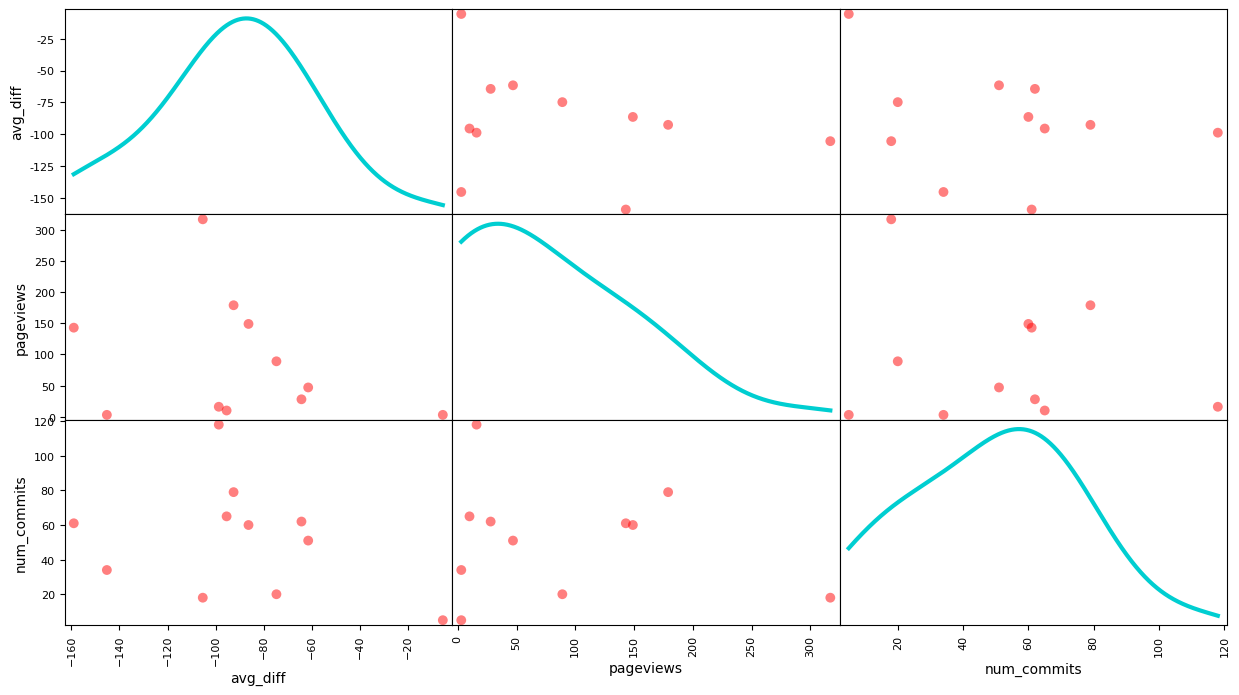

In [72]:
scatter_matrix(df[['avg_diff', 'pageviews', 'num_commits']], 
               figsize=(15, 8),
               s=200,
               diagonal='kde',
               color='#FF0000',
               hist_kwds={'edgecolor': 'black'},
               density_kwds={'linewidth': 3, 'color': '#00CED1'})
import matplotlib.pyplot as plt
plt.show()

In [73]:
conn.close()

Можем ли мы утверждать, что если у пользователя небольшое количество просмотров страницы, то у него, вероятно, будет небольшое количество коммитов?

**Нет**

Можем ли мы утверждать, что если у пользователя небольшое количество просмотров страницы, то у него, вероятно, будет малая средняя разница между первым коммитом и дедлайном лабораторной?

**Нет**

Можем ли мы утверждать, что у многих пользователей небольшое количество коммитов и у немногих - большое количество коммитов?

**Да**

Можем ли мы утверждать, что у многих пользователей малая средняя разница между первым коммитом и дедлайном и у немногих - большая средняя разница?

**Нет**